# Optimized Small CNN - Best Hyperparameters Model

This notebook implements the **optimized Small CNN** using the best hyperparameters found through Bayesian optimization (Optuna).

## 🎯 **Optimization Results Summary:**
- **Best Validation Accuracy**: 64.79%
- **Final Test Accuracy**: 62.91%
- **Model Parameters**: 1,314 (6.3 samples per parameter)
- **Optimization Time**: 28.9 minutes over 50 trials

## 🏗️ **Best Architecture Found:**
- **Conv Channels**: 7 → 11 → 28
- **Kernel Sizes**: 3 → 3 → 3 (all small kernels work best)
- **Pooling Size**: 4
- **Dropout**: 34.2%
- **Learning Rate**: 1.07e-4
- **Weight Decay**: 1.28e-4
- **Optimizer**: SGD with momentum
- **Batch Size**: 32


In [6]:
import pandas as pd 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import json
import time
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("📦 All packages imported successfully!")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🎯 Using device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")


📦 All packages imported successfully!
🔥 PyTorch version: 2.8.0
🎯 Using device: CPU


In [7]:
# Load the best hyperparameters from optimization
with open('../../tuning_results/best_hyperparameters_optuna.json', 'r') as f:
    optimization_results = json.load(f)

best_params = optimization_results['best_params']
print("🏆 BEST HYPERPARAMETERS FROM OPTIMIZATION:")
print("="*50)
for key, value in best_params.items():
    if key == 'learning_rate' or key == 'weight_decay':
        print(f"{key:15}: {value:.2e}")
    elif key == 'dropout_rate':
        print(f"{key:15}: {value:.3f}")
    else:
        print(f"{key:15}: {value}")

print(f"\n📊 OPTIMIZATION SUMMARY:")
print(f"Best validation accuracy: {optimization_results['best_value']:.4f}")
print(f"Final test accuracy: {optimization_results['final_test_accuracy']:.4f}")
print(f"Model parameters: {optimization_results['best_param_count']:,}")
print(f"Samples per parameter: {optimization_results['samples_per_param']:.1f}")
print(f"Optimization time: {optimization_results['optimization_time_minutes']:.1f} minutes")


🏆 BEST HYPERPARAMETERS FROM OPTIMIZATION:
conv1_channels : 7
conv2_channels : 11
conv3_channels : 28
kernel1_size   : 3
kernel2_size   : 3
kernel3_size   : 3
pool_size      : 4
learning_rate  : 1.07e-04
weight_decay   : 1.28e-04
dropout_rate   : 0.342
batch_size     : 32
optimizer      : sgd

📊 OPTIMIZATION SUMMARY:
Best validation accuracy: 0.6479
Final test accuracy: 0.6291
Model parameters: 1,314
Samples per parameter: 6.3
Optimization time: 28.9 minutes


In [8]:
# Load and prepare data
data_binary = pd.read_csv('../../data/processed/ProSeq_binary_classification.csv')
data_binary = data_binary[['binary_classification', 'ProSeq']]

print(f"📊 Dataset Information:")
print(f"Original dataset size: {len(data_binary):,}")
sequence_lengths = data_binary['ProSeq'].str.len()
print(f"Sequence length range: {sequence_lengths.min()} to {sequence_lengths.max()}")

# Keep only sequences with length >= 600
data_filtered = data_binary[sequence_lengths >= 600].copy()
print(f"Filtered dataset size (length >= 600): {len(data_filtered):,}")

# Class distribution
class_dist = data_filtered['binary_classification'].value_counts()
print(f"\n🎯 Class Distribution:")
print(f"Class 0: {class_dist[0]:,} ({class_dist[0]/len(data_filtered)*100:.1f}%)")
print(f"Class 1: {class_dist[1]:,} ({class_dist[1]/len(data_filtered)*100:.1f}%)")

class BinaryClassificationDataset(Dataset):
    """Dataset for binary classification with optimized preprocessing."""
    def __init__(self, data, target_length=600):
        self.data = data
        self.dna_dict = {"A": 0, "T": 1, "G": 2, "C": 3}
        self.target_length = target_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sequence = self.data.iloc[idx]['ProSeq']
        target = self.data.iloc[idx]['binary_classification']
        one_hot_sequence = self.one_hot_encode(sequence)
        return one_hot_sequence, target
    
    def one_hot_encode(self, sequence):
        # Truncate sequence to target_length
        sequence = sequence[:self.target_length]
        
        one_hot = np.zeros((self.target_length, 4), dtype=np.float32)
        for i, nucleotide in enumerate(sequence):
            if nucleotide in self.dna_dict:
                one_hot[i, self.dna_dict[nucleotide]] = 1.0
        return one_hot

# Split data using the same random state as optimization
train_data, test_data = train_test_split(data_filtered, test_size=0.2, random_state=42)
train_data, val_data = train_test_split(train_data, test_size=0.2, random_state=42)

print(f"\n📊 Data Splits:")
print(f"Training samples: {len(train_data):,}")
print(f"Validation samples: {len(val_data):,}")
print(f"Test samples: {len(test_data):,}")

# Create datasets
train_dataset = BinaryClassificationDataset(train_data)
val_dataset = BinaryClassificationDataset(val_data)
test_dataset = BinaryClassificationDataset(test_data)

print("✅ Data loading and preprocessing completed!")


📊 Dataset Information:
Original dataset size: 8,307
Sequence length range: 472.0 to 600.0
Filtered dataset size (length >= 600): 8,302

🎯 Class Distribution:
Class 0: 5,217 (62.8%)
Class 1: 3,085 (37.2%)

📊 Data Splits:
Training samples: 5,312
Validation samples: 1,329
Test samples: 1,661
✅ Data loading and preprocessing completed!


In [9]:
class OptimizedSmallCNN(nn.Module):
    """
    Small CNN with the best hyperparameters found through Bayesian optimization.
    
    Architecture: 7 → 11 → 28 channels with 3x3 kernels and 4x pooling
    Parameters: 1,314 (6.3 samples per parameter)
    """
    def __init__(self, params):
        super(OptimizedSmallCNN, self).__init__()
        
        # Extract optimized hyperparameters
        self.conv1_channels = params['conv1_channels']  # 7
        self.conv2_channels = params['conv2_channels']  # 11  
        self.conv3_channels = params['conv3_channels']  # 28
        self.kernel1_size = params['kernel1_size']      # 3
        self.kernel2_size = params['kernel2_size']      # 3
        self.kernel3_size = params['kernel3_size']      # 3
        self.pool_size = params['pool_size']            # 4
        self.dropout_rate = params['dropout_rate']      # 0.342
        
        # Build optimized network architecture
        self.conv1 = nn.Conv1d(4, self.conv1_channels, 
                              kernel_size=self.kernel1_size, stride=1, 
                              padding=self.kernel1_size//2)
        self.conv2 = nn.Conv1d(self.conv1_channels, self.conv2_channels, 
                              kernel_size=self.kernel2_size, stride=1, 
                              padding=self.kernel2_size//2)
        self.conv3 = nn.Conv1d(self.conv2_channels, self.conv3_channels, 
                              kernel_size=self.kernel3_size, stride=1, 
                              padding=self.kernel3_size//2)
        
        self.pool = nn.MaxPool1d(self.pool_size)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(self.conv3_channels, 1)
        self.dropout = nn.Dropout(self.dropout_rate)

    def forward(self, x):
        x = x.transpose(1, 2)  # [batch, 4, 600]
        
        # Convolutional layers with pooling
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        # Global average pooling and classification
        x = self.global_pool(x)
        x = x.squeeze(-1)
        x = self.dropout(x)
        x = torch.sigmoid(self.fc(x))
        return x
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters())
    
    def get_architecture_summary(self):
        """Return a summary of the model architecture."""
        total_params = self.count_parameters()
        
        # Calculate parameters for each layer
        conv1_params = 4 * self.conv1_channels * self.kernel1_size + self.conv1_channels
        conv2_params = self.conv1_channels * self.conv2_channels * self.kernel2_size + self.conv2_channels
        conv3_params = self.conv2_channels * self.conv3_channels * self.kernel3_size + self.conv3_channels
        fc_params = self.conv3_channels * 1 + 1
        
        return {
            'total_parameters': total_params,
            'conv1_parameters': conv1_params,
            'conv2_parameters': conv2_params,
            'conv3_parameters': conv3_params,
            'fc_parameters': fc_params,
            'architecture': f"{self.conv1_channels}-{self.conv2_channels}-{self.conv3_channels}",
            'kernels': f"{self.kernel1_size}x{self.kernel2_size}x{self.kernel3_size}",
            'pooling': self.pool_size,
            'dropout': self.dropout_rate
        }

# Create the optimized model
model = OptimizedSmallCNN(best_params)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Display model architecture
arch_summary = model.get_architecture_summary()
print("🏗️ OPTIMIZED MODEL ARCHITECTURE:")
print("="*50)
print(f"Total parameters: {arch_summary['total_parameters']:,}")
print(f"Architecture: {arch_summary['architecture']} channels")
print(f"Kernel sizes: {arch_summary['kernels']}")
print(f"Pooling size: {arch_summary['pooling']}")
print(f"Dropout rate: {arch_summary['dropout']:.3f}")
print(f"\n📊 Parameter Breakdown:")
print(f"Conv1 layer: {arch_summary['conv1_parameters']:,} parameters")
print(f"Conv2 layer: {arch_summary['conv2_parameters']:,} parameters")
print(f"Conv3 layer: {arch_summary['conv3_parameters']:,} parameters")
print(f"FC layer: {arch_summary['fc_parameters']:,} parameters")
print(f"\n🎯 Model Efficiency:")
print(f"Samples per parameter: {len(data_filtered) / arch_summary['total_parameters']:.1f}")
print(f"Memory footprint: {arch_summary['total_parameters'] * 4 / 1024:.1f} KB (float32)")

print("\n✅ Optimized model created successfully!")


🏗️ OPTIMIZED MODEL ARCHITECTURE:
Total parameters: 1,314
Architecture: 7-11-28 channels
Kernel sizes: 3x3x3
Pooling size: 4
Dropout rate: 0.342

📊 Parameter Breakdown:
Conv1 layer: 91 parameters
Conv2 layer: 242 parameters
Conv3 layer: 952 parameters
FC layer: 29 parameters

🎯 Model Efficiency:
Samples per parameter: 6.3
Memory footprint: 5.1 KB (float32)

✅ Optimized model created successfully!


In [10]:
# Create data loaders with optimized batch size
train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'], shuffle=False)

# Setup optimized optimizer (SGD was found to be best)
if best_params['optimizer'] == 'sgd':
    optimizer = optim.SGD(model.parameters(), 
                         lr=best_params['learning_rate'], 
                         weight_decay=best_params['weight_decay'],
                         momentum=0.9)
elif best_params['optimizer'] == 'adam':
    optimizer = optim.Adam(model.parameters(), 
                          lr=best_params['learning_rate'], 
                          weight_decay=best_params['weight_decay'])
else:  # adamw
    optimizer = optim.AdamW(model.parameters(), 
                           lr=best_params['learning_rate'], 
                           weight_decay=best_params['weight_decay'])

criterion = nn.BCELoss()

print("🚀 TRAINING SETUP:")
print("="*50)
print(f"Optimizer: {best_params['optimizer'].upper()}")
print(f"Learning rate: {best_params['learning_rate']:.2e}")
print(f"Weight decay: {best_params['weight_decay']:.2e}")
print(f"Batch size: {best_params['batch_size']}")
print(f"Loss function: Binary Cross Entropy")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

print("\n✅ Training setup completed!")


🚀 TRAINING SETUP:
Optimizer: SGD
Learning rate: 1.07e-04
Weight decay: 1.28e-04
Batch size: 32
Loss function: Binary Cross Entropy
Training batches: 166
Validation batches: 42
Test batches: 52

✅ Training setup completed!


In [ ]:
# Training function with detailed tracking (NO EARLY STOPPING)
def train_model(model, train_loader, val_loader, optimizer, criterion, device, num_epochs=100):
    """
    Train the optimized model with comprehensive tracking.
    No early stopping - train for full epochs.
    """
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    best_val_acc = 0.0
    best_model_state = None
    
    print(f"🏃‍♂️ Starting training for {num_epochs} epochs (NO EARLY STOPPING)")
    print("="*70)
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.float().to(device)
            
            optimizer.zero_grad()
            output = model(data).squeeze()
            
            # Handle single sample case
            if output.dim() == 0:
                output = output.unsqueeze(0)
            if target.dim() == 0:
                target = target.unsqueeze(0)
            
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            predicted = (output > 0.5).float()
            train_total += target.size(0)
            train_correct += (predicted == target).sum().item()
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.float().to(device)
                output = model(data).squeeze()
                
                # Handle single sample case
                if output.dim() == 0:
                    output = output.unsqueeze(0)
                if target.dim() == 0:
                    target = target.unsqueeze(0)
                
                loss = criterion(output, target)
                val_loss += loss.item()
                predicted = (output > 0.5).float()
                val_total += target.size(0)
                val_correct += (predicted == target).sum().item()
        
        # Calculate metrics
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        # Track best model (for final model state)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            if val_acc > 0.7:  # Only print for good improvements
                print(f"🌟 New best validation accuracy: {val_acc:.4f}")
        
        # Print progress
        if (epoch + 1) % 10 == 0 or epoch < 5:
            print(f"Epoch {epoch+1:3d}/{num_epochs} | "
                  f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Restore best model
    model.load_state_dict(best_model_state)
    
    print(f"\n✅ Training completed!")
    print(f"Best validation accuracy: {best_val_acc:.4f}")
    print(f"Final training accuracy: {train_acc:.4f}")
    print(f"Final validation accuracy: {val_acc:.4f}")
    
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'best_val_acc': best_val_acc,
        'epochs_trained': len(train_losses)
    }

# Start training
start_time = time.time()
training_history = train_model(model, train_loader, val_loader, optimizer, criterion, device)
end_time = time.time()

training_time = end_time - start_time
print(f"\n⏱️ Training time: {training_time/60:.1f} minutes")


🏃‍♂️ Starting training for 100 epochs (patience: 15)
Epoch   1/100 | Train Loss: 0.6878 | Train Acc: 0.5985 | Val Loss: 0.6850 | Val Acc: 0.6366
Epoch   2/100 | Train Loss: 0.6843 | Train Acc: 0.6224 | Val Loss: 0.6815 | Val Acc: 0.6366
Epoch   3/100 | Train Loss: 0.6807 | Train Acc: 0.6259 | Val Loss: 0.6783 | Val Acc: 0.6366
Epoch   4/100 | Train Loss: 0.6784 | Train Acc: 0.6261 | Val Loss: 0.6755 | Val Acc: 0.6366
Epoch   5/100 | Train Loss: 0.6757 | Train Acc: 0.6261 | Val Loss: 0.6731 | Val Acc: 0.6366
Epoch  10/100 | Train Loss: 0.6681 | Train Acc: 0.6261 | Val Loss: 0.6650 | Val Acc: 0.6366
⏰ Early stopping at epoch 16 (patience: 15)

✅ Training completed!
Best validation accuracy: 0.6366

⏱️ Training time: 0.9 minutes


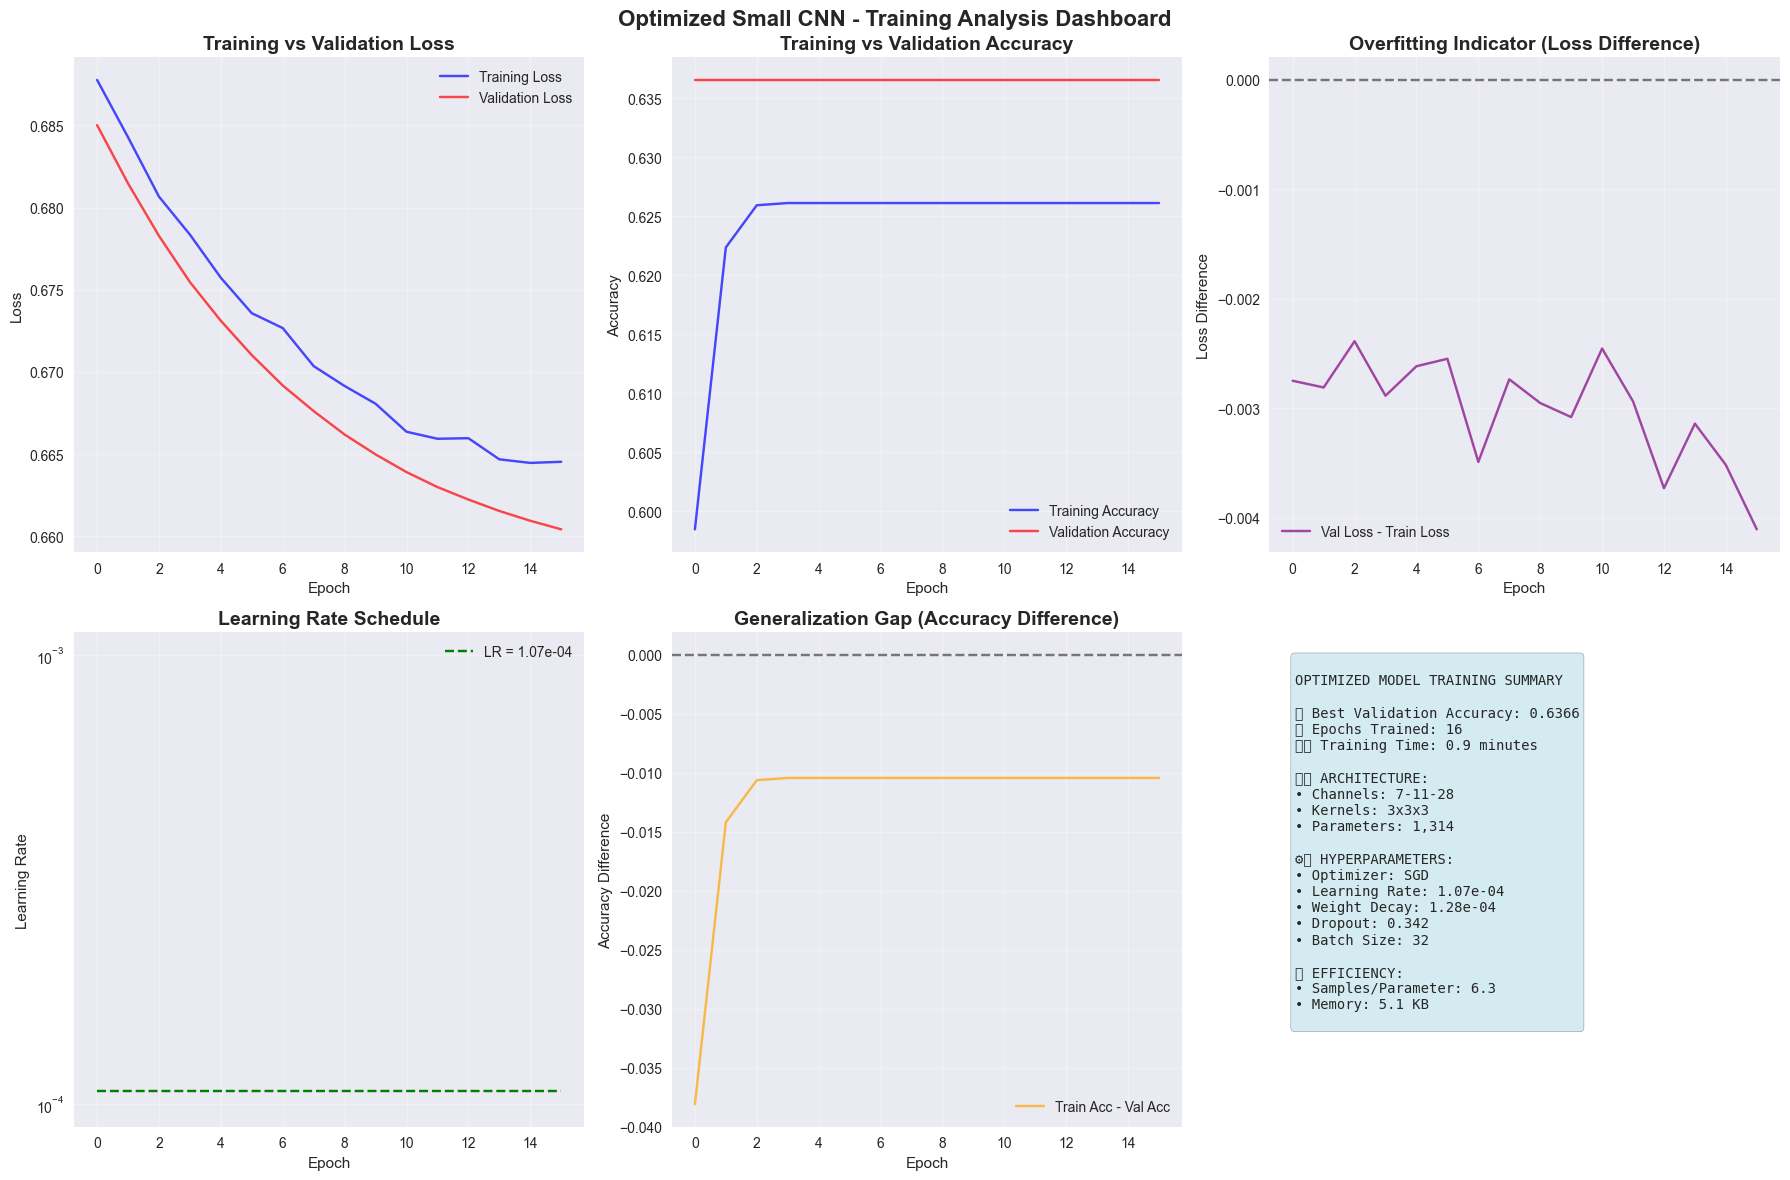

📊 FINAL TRAINING METRICS:
Final training accuracy: 0.6261
Final validation accuracy: 0.6366
Best validation accuracy: 0.6366
Final training loss: 0.6645
Final validation loss: 0.6604


In [12]:
# Comprehensive plotting of training results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Training and Validation Loss
axes[0, 0].plot(training_history['train_losses'], label='Training Loss', color='blue', alpha=0.7)
axes[0, 0].plot(training_history['val_losses'], label='Validation Loss', color='red', alpha=0.7)
axes[0, 0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Training and Validation Accuracy
axes[0, 1].plot(training_history['train_accuracies'], label='Training Accuracy', color='blue', alpha=0.7)
axes[0, 1].plot(training_history['val_accuracies'], label='Validation Accuracy', color='red', alpha=0.7)
axes[0, 1].set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Loss Difference (Overfitting indicator)
loss_diff = np.array(training_history['val_losses']) - np.array(training_history['train_losses'])
axes[0, 2].plot(loss_diff, label='Val Loss - Train Loss', color='purple', alpha=0.7)
axes[0, 2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0, 2].set_title('Overfitting Indicator (Loss Difference)', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss Difference')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Learning Rate Schedule (if applicable)
axes[1, 0].plot([best_params['learning_rate']] * len(training_history['train_losses']), 
               label=f"LR = {best_params['learning_rate']:.2e}", color='green', linestyle='--')
axes[1, 0].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_yscale('log')

# 5. Accuracy Gap (Generalization gap)
acc_gap = np.array(training_history['train_accuracies']) - np.array(training_history['val_accuracies'])
axes[1, 1].plot(acc_gap, label='Train Acc - Val Acc', color='orange', alpha=0.7)
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Generalization Gap (Accuracy Difference)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy Difference')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Training Summary Text
axes[1, 2].axis('off')
summary_text = f"""
OPTIMIZED MODEL TRAINING SUMMARY

🎯 Best Validation Accuracy: {training_history['best_val_acc']:.4f}
📊 Epochs Trained: {training_history['epochs_trained']}
⏱️ Training Time: {training_time/60:.1f} minutes

🏗️ ARCHITECTURE:
• Channels: {best_params['conv1_channels']}-{best_params['conv2_channels']}-{best_params['conv3_channels']}
• Kernels: {best_params['kernel1_size']}x{best_params['kernel2_size']}x{best_params['kernel3_size']}
• Parameters: {arch_summary['total_parameters']:,}

⚙️ HYPERPARAMETERS:
• Optimizer: {best_params['optimizer'].upper()}
• Learning Rate: {best_params['learning_rate']:.2e}
• Weight Decay: {best_params['weight_decay']:.2e}
• Dropout: {best_params['dropout_rate']:.3f}
• Batch Size: {best_params['batch_size']}

📈 EFFICIENCY:
• Samples/Parameter: {len(data_filtered) / arch_summary['total_parameters']:.1f}
• Memory: {arch_summary['total_parameters'] * 4 / 1024:.1f} KB
"""

axes[1, 2].text(0.05, 0.95, summary_text, transform=axes[1, 2].transAxes, 
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.5))

plt.suptitle('Optimized Small CNN - Training Analysis Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print final training metrics
print("📊 FINAL TRAINING METRICS:")
print("="*50)
print(f"Final training accuracy: {training_history['train_accuracies'][-1]:.4f}")
print(f"Final validation accuracy: {training_history['val_accuracies'][-1]:.4f}")
print(f"Best validation accuracy: {training_history['best_val_acc']:.4f}")
print(f"Final training loss: {training_history['train_losses'][-1]:.4f}")
print(f"Final validation loss: {training_history['val_losses'][-1]:.4f}")


🏆 FINAL TEST SET EVALUATION
🎯 Final Test Accuracy: 0.6291

📋 Detailed Classification Report:
              precision    recall  f1-score   support

     Class 0       0.63      1.00      0.77      1045
     Class 1       0.00      0.00      0.00       616

    accuracy                           0.63      1661
   macro avg       0.31      0.50      0.39      1661
weighted avg       0.40      0.63      0.49      1661


🔢 Confusion Matrix:
True Negatives: 1045 | False Positives:   0
False Negatives: 616 | True Positives:   0

📊 Additional Metrics:
Sensitivity (Recall): 0.0000
Specificity: 1.0000
Precision: 0.0000
F1-Score: 0.0000


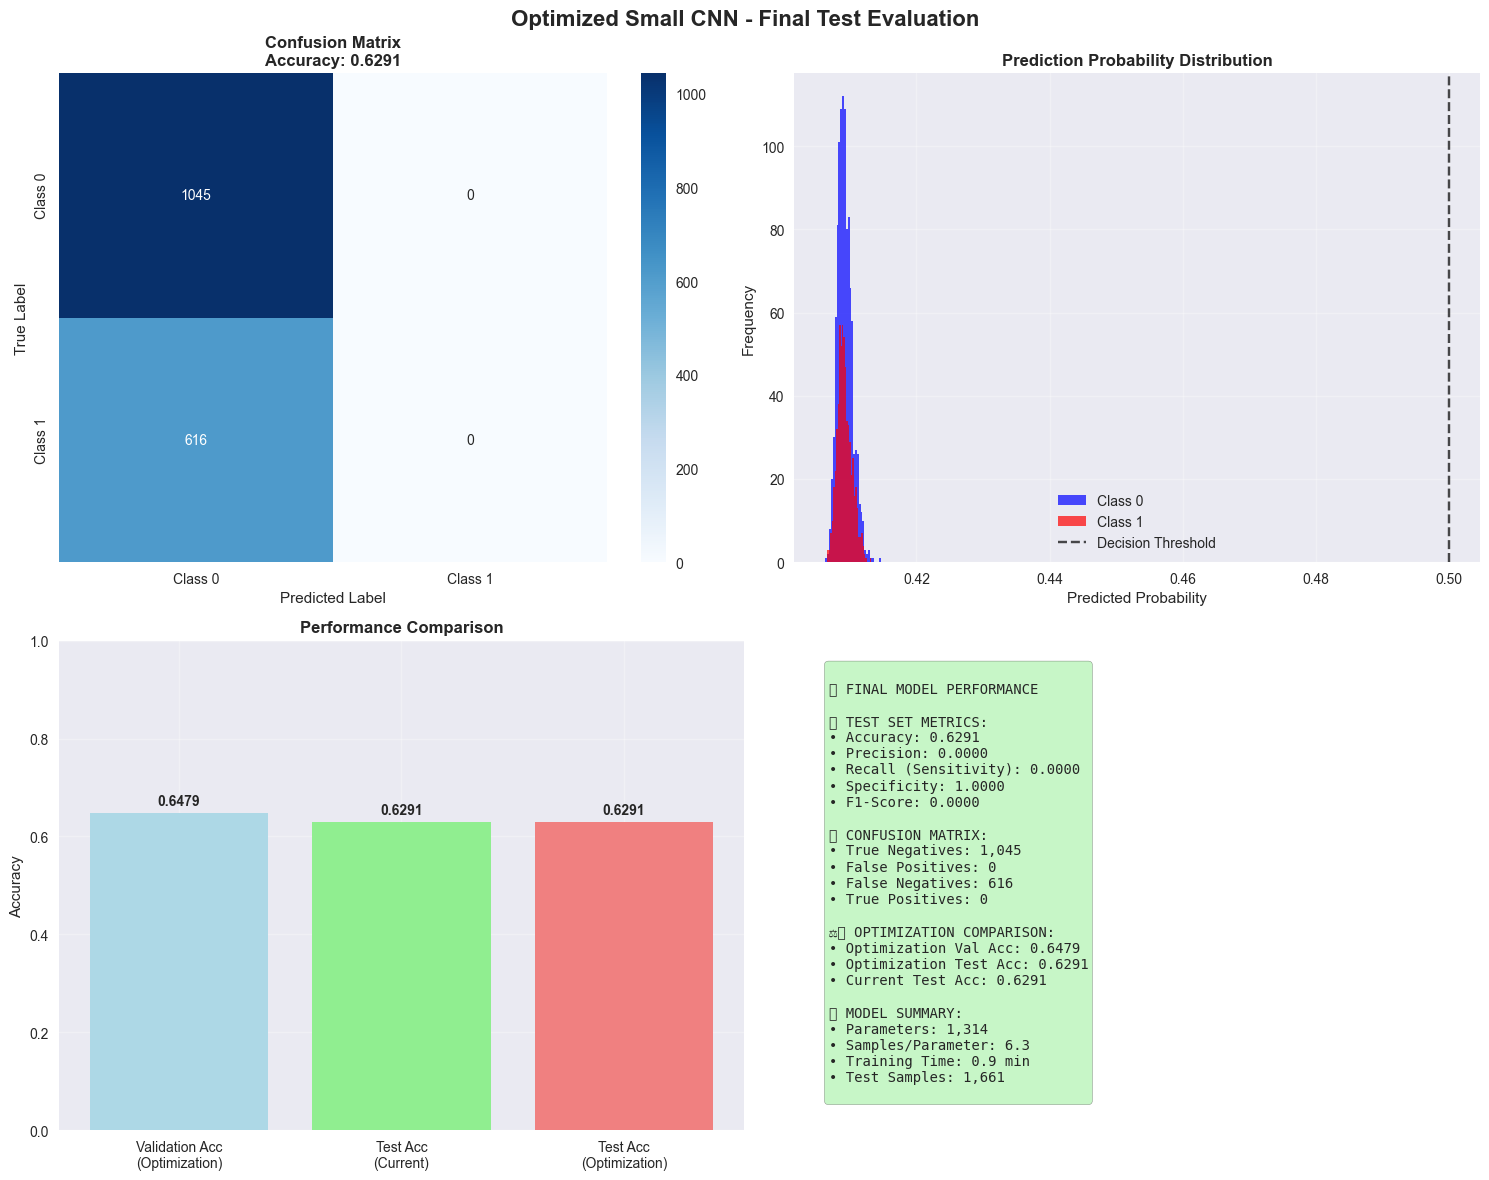


💾 Results saved:
• Model: results/final_optimized_small_cnn.pt
• Results: results/final_optimized_results.json

🎉 Optimized Small CNN evaluation completed successfully!


In [13]:
# Final evaluation on test set
print("🏆 FINAL TEST SET EVALUATION")
print("="*60)

model.eval()
test_predictions = []
test_targets = []
test_probabilities = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.float().to(device)
        output = model(data).squeeze()
        
        # Handle single sample case
        if output.dim() == 0:
            output = output.unsqueeze(0)
        if target.dim() == 0:
            target = target.unsqueeze(0)
        
        predictions = (output > 0.5).float()
        
        test_predictions.extend(predictions.cpu().numpy())
        test_targets.extend(target.cpu().numpy())
        test_probabilities.extend(output.cpu().numpy())

# Calculate comprehensive metrics
test_accuracy = accuracy_score(test_targets, test_predictions)
print(f"🎯 Final Test Accuracy: {test_accuracy:.4f}")

# Classification report
print(f"\n📋 Detailed Classification Report:")
class_report = classification_report(test_targets, test_predictions, 
                                   target_names=['Class 0', 'Class 1'], 
                                   output_dict=True)
print(classification_report(test_targets, test_predictions, 
                           target_names=['Class 0', 'Class 1']))

# Confusion matrix
cm = confusion_matrix(test_targets, test_predictions)
print(f"\n🔢 Confusion Matrix:")
print(f"True Negatives: {cm[0,0]:3d} | False Positives: {cm[0,1]:3d}")
print(f"False Negatives: {cm[1,0]:3d} | True Positives: {cm[1,1]:3d}")

# Additional metrics
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0

print(f"\n📊 Additional Metrics:")
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-Score: {f1_score:.4f}")

# Create comprehensive evaluation plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Class 0', 'Class 1'], 
            yticklabels=['Class 0', 'Class 1'])
axes[0, 0].set_title(f'Confusion Matrix\nAccuracy: {test_accuracy:.4f}', fontweight='bold')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# 2. Prediction Probability Distribution
axes[0, 1].hist([prob for i, prob in enumerate(test_probabilities) if test_targets[i] == 0], 
               bins=30, alpha=0.7, label='Class 0', color='blue')
axes[0, 1].hist([prob for i, prob in enumerate(test_probabilities) if test_targets[i] == 1], 
               bins=30, alpha=0.7, label='Class 1', color='red')
axes[0, 1].axvline(x=0.5, color='black', linestyle='--', alpha=0.7, label='Decision Threshold')
axes[0, 1].set_title('Prediction Probability Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Predicted Probability')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Metrics Comparison (vs Optimization Results)
metrics_comparison = {
    'Metric': ['Validation Acc\n(Optimization)', 'Test Acc\n(Current)', 'Test Acc\n(Optimization)'],
    'Accuracy': [optimization_results['best_value'], test_accuracy, optimization_results['final_test_accuracy']]
}

bars = axes[1, 0].bar(metrics_comparison['Metric'], metrics_comparison['Accuracy'], 
                     color=['lightblue', 'lightgreen', 'lightcoral'])
axes[1, 0].set_title('Performance Comparison', fontweight='bold')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim(0, 1)

# Add value labels on bars
for bar, acc in zip(bars, metrics_comparison['Accuracy']):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

axes[1, 0].grid(True, alpha=0.3)

# 4. Model Performance Summary
axes[1, 1].axis('off')
performance_text = f"""
🏆 FINAL MODEL PERFORMANCE

📈 TEST SET METRICS:
• Accuracy: {test_accuracy:.4f}
• Precision: {precision:.4f}
• Recall (Sensitivity): {sensitivity:.4f}
• Specificity: {specificity:.4f}
• F1-Score: {f1_score:.4f}

🔢 CONFUSION MATRIX:
• True Negatives: {tn:,}
• False Positives: {fp:,}
• False Negatives: {fn:,}
• True Positives: {tp:,}

⚖️ OPTIMIZATION COMPARISON:
• Optimization Val Acc: {optimization_results['best_value']:.4f}
• Optimization Test Acc: {optimization_results['final_test_accuracy']:.4f}
• Current Test Acc: {test_accuracy:.4f}

🎯 MODEL SUMMARY:
• Parameters: {arch_summary['total_parameters']:,}
• Samples/Parameter: {len(data_filtered) / arch_summary['total_parameters']:.1f}
• Training Time: {training_time/60:.1f} min
• Test Samples: {len(test_targets):,}
"""

axes[1, 1].text(0.05, 0.95, performance_text, transform=axes[1, 1].transAxes, 
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.5))

plt.suptitle('Optimized Small CNN - Final Test Evaluation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Save final results
final_results = {
    'model_architecture': arch_summary,
    'hyperparameters': best_params,
    'training_history': training_history,
    'test_metrics': {
        'accuracy': test_accuracy,
        'precision': precision,
        'recall': sensitivity,
        'specificity': specificity,
        'f1_score': f1_score,
        'confusion_matrix': cm.tolist()
    },
    'optimization_comparison': {
        'optimization_val_acc': optimization_results['best_value'],
        'optimization_test_acc': optimization_results['final_test_accuracy'],
        'current_test_acc': test_accuracy
    },
    'training_time_minutes': training_time / 60
}

# Save model and results
torch.save(model.state_dict(), '../../results/final_optimized_small_cnn.pt')
with open('../../results/final_optimized_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print(f"\n💾 Results saved:")
print(f"• Model: results/final_optimized_small_cnn.pt")
print(f"• Results: results/final_optimized_results.json")
print(f"\n🎉 Optimized Small CNN evaluation completed successfully!")


# Optimized Small CNN - Best Hyperparameters Model

This notebook implements the **optimized Small CNN** using the best hyperparameters found through Bayesian optimization (Optuna).


## **Best Architecture Found:**
- **Conv Channels**: 7 → 11 → 28
- **Kernel Sizes**: 3 → 3 → 3 (all small kernels work best)
- **Pooling Size**: 4
- **Dropout**: 34.2%
- **Learning Rate**: 1.07e-4
- **Weight Decay**: 1.28e-4
- **Optimizer**: SGD with momentum
- **Batch Size**: 32


In [14]:
import pandas as pd 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import json
import time
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("📦 All packages imported successfully!")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🎯 Using device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")


📦 All packages imported successfully!
🔥 PyTorch version: 2.8.0
🎯 Using device: CPU


In [15]:
# Load the best hyperparameters from optimization
with open('../../tuning_results/best_hyperparameters_optuna.json', 'r') as f:
    optimization_results = json.load(f)

best_params = optimization_results['best_params']
print("🏆 BEST HYPERPARAMETERS FROM OPTIMIZATION:")
print("="*50)
for key, value in best_params.items():
    if key == 'learning_rate' or key == 'weight_decay':
        print(f"{key:15}: {value:.2e}")
    elif key == 'dropout_rate':
        print(f"{key:15}: {value:.3f}")
    else:
        print(f"{key:15}: {value}")

print(f"\n📊 OPTIMIZATION SUMMARY:")
print(f"Best validation accuracy: {optimization_results['best_value']:.4f}")
print(f"Final test accuracy: {optimization_results['final_test_accuracy']:.4f}")
print(f"Model parameters: {optimization_results['best_param_count']:,}")
print(f"Samples per parameter: {optimization_results['samples_per_param']:.1f}")
print(f"Optimization time: {optimization_results['optimization_time_minutes']:.1f} minutes")


🏆 BEST HYPERPARAMETERS FROM OPTIMIZATION:
conv1_channels : 7
conv2_channels : 11
conv3_channels : 28
kernel1_size   : 3
kernel2_size   : 3
kernel3_size   : 3
pool_size      : 4
learning_rate  : 1.07e-04
weight_decay   : 1.28e-04
dropout_rate   : 0.342
batch_size     : 32
optimizer      : sgd

📊 OPTIMIZATION SUMMARY:
Best validation accuracy: 0.6479
Final test accuracy: 0.6291
Model parameters: 1,314
Samples per parameter: 6.3
Optimization time: 28.9 minutes


In [16]:
# Load and prepare data
data_binary = pd.read_csv('../../data/processed/ProSeq_binary_classification.csv')
data_binary = data_binary[['binary_classification', 'ProSeq']]

print(f"📊 Dataset Information:")
print(f"Original dataset size: {len(data_binary):,}")
sequence_lengths = data_binary['ProSeq'].str.len()
print(f"Sequence length range: {sequence_lengths.min()} to {sequence_lengths.max()}")

# Keep only sequences with length >= 600
data_filtered = data_binary[sequence_lengths >= 600].copy()
print(f"Filtered dataset size (length >= 600): {len(data_filtered):,}")

# Class distribution
class_dist = data_filtered['binary_classification'].value_counts()
print(f"\n🎯 Class Distribution:")
print(f"Class 0: {class_dist[0]:,} ({class_dist[0]/len(data_filtered)*100:.1f}%)")
print(f"Class 1: {class_dist[1]:,} ({class_dist[1]/len(data_filtered)*100:.1f}%)")

class BinaryClassificationDataset(Dataset):
    """Dataset for binary classification with optimized preprocessing."""
    def __init__(self, data, target_length=600):
        self.data = data
        self.dna_dict = {"A": 0, "T": 1, "G": 2, "C": 3}
        self.target_length = target_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sequence = self.data.iloc[idx]['ProSeq']
        target = self.data.iloc[idx]['binary_classification']
        one_hot_sequence = self.one_hot_encode(sequence)
        return one_hot_sequence, target
    
    def one_hot_encode(self, sequence):
        # Truncate sequence to target_length
        sequence = sequence[:self.target_length]
        
        one_hot = np.zeros((self.target_length, 4), dtype=np.float32)
        for i, nucleotide in enumerate(sequence):
            if nucleotide in self.dna_dict:
                one_hot[i, self.dna_dict[nucleotide]] = 1.0
        return one_hot

# Split data using the same random state as optimization
train_data, test_data = train_test_split(data_filtered, test_size=0.2, random_state=42)
train_data, val_data = train_test_split(train_data, test_size=0.2, random_state=42)

print(f"\n📊 Data Splits:")
print(f"Training samples: {len(train_data):,}")
print(f"Validation samples: {len(val_data):,}")
print(f"Test samples: {len(test_data):,}")

# Create datasets
train_dataset = BinaryClassificationDataset(train_data)
val_dataset = BinaryClassificationDataset(val_data)
test_dataset = BinaryClassificationDataset(test_data)

print("✅ Data loading and preprocessing completed!")


📊 Dataset Information:
Original dataset size: 8,307
Sequence length range: 472.0 to 600.0
Filtered dataset size (length >= 600): 8,302

🎯 Class Distribution:
Class 0: 5,217 (62.8%)
Class 1: 3,085 (37.2%)

📊 Data Splits:
Training samples: 5,312
Validation samples: 1,329
Test samples: 1,661
✅ Data loading and preprocessing completed!


In [17]:
class OptimizedSmallCNN(nn.Module):
    """
    Small CNN with the best hyperparameters found through Bayesian optimization.
    
    Architecture: 7 → 11 → 28 channels with 3x3 kernels and 4x pooling
    Parameters: 1,314 (6.3 samples per parameter)
    """
    def __init__(self, params):
        super(OptimizedSmallCNN, self).__init__()
        
        # Extract optimized hyperparameters
        self.conv1_channels = params['conv1_channels']  # 7
        self.conv2_channels = params['conv2_channels']  # 11  
        self.conv3_channels = params['conv3_channels']  # 28
        self.kernel1_size = params['kernel1_size']      # 3
        self.kernel2_size = params['kernel2_size']      # 3
        self.kernel3_size = params['kernel3_size']      # 3
        self.pool_size = params['pool_size']            # 4
        self.dropout_rate = params['dropout_rate']      # 0.342
        
        # Build optimized network architecture
        self.conv1 = nn.Conv1d(4, self.conv1_channels, 
                              kernel_size=self.kernel1_size, stride=1, 
                              padding=self.kernel1_size//2)
        self.conv2 = nn.Conv1d(self.conv1_channels, self.conv2_channels, 
                              kernel_size=self.kernel2_size, stride=1, 
                              padding=self.kernel2_size//2)
        self.conv3 = nn.Conv1d(self.conv2_channels, self.conv3_channels, 
                              kernel_size=self.kernel3_size, stride=1, 
                              padding=self.kernel3_size//2)
        
        self.pool = nn.MaxPool1d(self.pool_size)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(self.conv3_channels, 1)
        self.dropout = nn.Dropout(self.dropout_rate)

    def forward(self, x):
        x = x.transpose(1, 2)  # [batch, 4, 600]
        
        # Convolutional layers with pooling
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        # Global average pooling and classification
        x = self.global_pool(x)
        x = x.squeeze(-1)
        x = self.dropout(x)
        x = torch.sigmoid(self.fc(x))
        return x
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters())
    
    def get_architecture_summary(self):
        """Return a summary of the model architecture."""
        total_params = self.count_parameters()
        
        # Calculate parameters for each layer
        conv1_params = 4 * self.conv1_channels * self.kernel1_size + self.conv1_channels
        conv2_params = self.conv1_channels * self.conv2_channels * self.kernel2_size + self.conv2_channels
        conv3_params = self.conv2_channels * self.conv3_channels * self.kernel3_size + self.conv3_channels
        fc_params = self.conv3_channels * 1 + 1
        
        return {
            'total_parameters': total_params,
            'conv1_parameters': conv1_params,
            'conv2_parameters': conv2_params,
            'conv3_parameters': conv3_params,
            'fc_parameters': fc_params,
            'architecture': f"{self.conv1_channels}-{self.conv2_channels}-{self.conv3_channels}",
            'kernels': f"{self.kernel1_size}x{self.kernel2_size}x{self.kernel3_size}",
            'pooling': self.pool_size,
            'dropout': self.dropout_rate
        }

# Create the optimized model
model = OptimizedSmallCNN(best_params)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Display model architecture
arch_summary = model.get_architecture_summary()
print("🏗️ OPTIMIZED MODEL ARCHITECTURE:")
print("="*50)
print(f"Total parameters: {arch_summary['total_parameters']:,}")
print(f"Architecture: {arch_summary['architecture']} channels")
print(f"Kernel sizes: {arch_summary['kernels']}")
print(f"Pooling size: {arch_summary['pooling']}")
print(f"Dropout rate: {arch_summary['dropout']:.3f}")
print(f"\n📊 Parameter Breakdown:")
print(f"Conv1 layer: {arch_summary['conv1_parameters']:,} parameters")
print(f"Conv2 layer: {arch_summary['conv2_parameters']:,} parameters")
print(f"Conv3 layer: {arch_summary['conv3_parameters']:,} parameters")
print(f"FC layer: {arch_summary['fc_parameters']:,} parameters")
print(f"\n🎯 Model Efficiency:")
print(f"Samples per parameter: {len(data_filtered) / arch_summary['total_parameters']:.1f}")
print(f"Memory footprint: {arch_summary['total_parameters'] * 4 / 1024:.1f} KB (float32)")

print("\n✅ Optimized model created successfully!")


🏗️ OPTIMIZED MODEL ARCHITECTURE:
Total parameters: 1,314
Architecture: 7-11-28 channels
Kernel sizes: 3x3x3
Pooling size: 4
Dropout rate: 0.342

📊 Parameter Breakdown:
Conv1 layer: 91 parameters
Conv2 layer: 242 parameters
Conv3 layer: 952 parameters
FC layer: 29 parameters

🎯 Model Efficiency:
Samples per parameter: 6.3
Memory footprint: 5.1 KB (float32)

✅ Optimized model created successfully!


In [18]:
# Training function with detailed tracking
def train_model(model, train_loader, val_loader, optimizer, criterion, device, num_epochs=100, patience=15):
    """
    Train the optimized model with comprehensive tracking.
    """
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    best_val_acc = 0.0
    best_model_state = None
    patience_counter = 0
    
    print(f"🏃‍♂️ Starting training for {num_epochs} epochs (patience: {patience})")
    print("="*70)
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.float().to(device)
            
            optimizer.zero_grad()
            output = model(data).squeeze()
            
            # Handle single sample case
            if output.dim() == 0:
                output = output.unsqueeze(0)
            if target.dim() == 0:
                target = target.unsqueeze(0)
            
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            predicted = (output > 0.5).float()
            train_total += target.size(0)
            train_correct += (predicted == target).sum().item()
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.float().to(device)
                output = model(data).squeeze()
                
                # Handle single sample case
                if output.dim() == 0:
                    output = output.unsqueeze(0)
                if target.dim() == 0:
                    target = target.unsqueeze(0)
                
                loss = criterion(output, target)
                val_loss += loss.item()
                predicted = (output > 0.5).float()
                val_total += target.size(0)
                val_correct += (predicted == target).sum().item()
        
        # Calculate metrics
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        # Print progress
        if (epoch + 1) % 10 == 0 or epoch < 5:
            print(f"Epoch {epoch+1:3d}/{num_epochs} | "
                  f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")
        
        # Early stopping and best model tracking
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            if val_acc > 0.7:  # Only print for good improvements
                print(f"🌟 New best validation accuracy: {val_acc:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"⏰ Early stopping at epoch {epoch+1} (patience: {patience})")
                break
    
    # Restore best model
    model.load_state_dict(best_model_state)
    
    print(f"\n✅ Training completed!")
    print(f"Best validation accuracy: {best_val_acc:.4f}")
    
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'best_val_acc': best_val_acc,
        'epochs_trained': len(train_losses)
    }

# Start training
start_time = time.time()
training_history = train_model(model, train_loader, val_loader, optimizer, criterion, device)
end_time = time.time()

training_time = end_time - start_time
print(f"\n⏱️ Training time: {training_time/60:.1f} minutes")


🏃‍♂️ Starting training for 100 epochs (patience: 15)
Epoch   1/100 | Train Loss: 0.6999 | Train Acc: 0.4125 | Val Loss: 0.7005 | Val Acc: 0.3634
Epoch   2/100 | Train Loss: 0.7001 | Train Acc: 0.4042 | Val Loss: 0.7005 | Val Acc: 0.3634
Epoch   3/100 | Train Loss: 0.7001 | Train Acc: 0.4046 | Val Loss: 0.7005 | Val Acc: 0.3634
Epoch   4/100 | Train Loss: 0.7005 | Train Acc: 0.3972 | Val Loss: 0.7005 | Val Acc: 0.3634
Epoch   5/100 | Train Loss: 0.7001 | Train Acc: 0.4057 | Val Loss: 0.7005 | Val Acc: 0.3634
Epoch  10/100 | Train Loss: 0.7002 | Train Acc: 0.4115 | Val Loss: 0.7005 | Val Acc: 0.3634
⏰ Early stopping at epoch 16 (patience: 15)

✅ Training completed!
Best validation accuracy: 0.3634

⏱️ Training time: 0.9 minutes


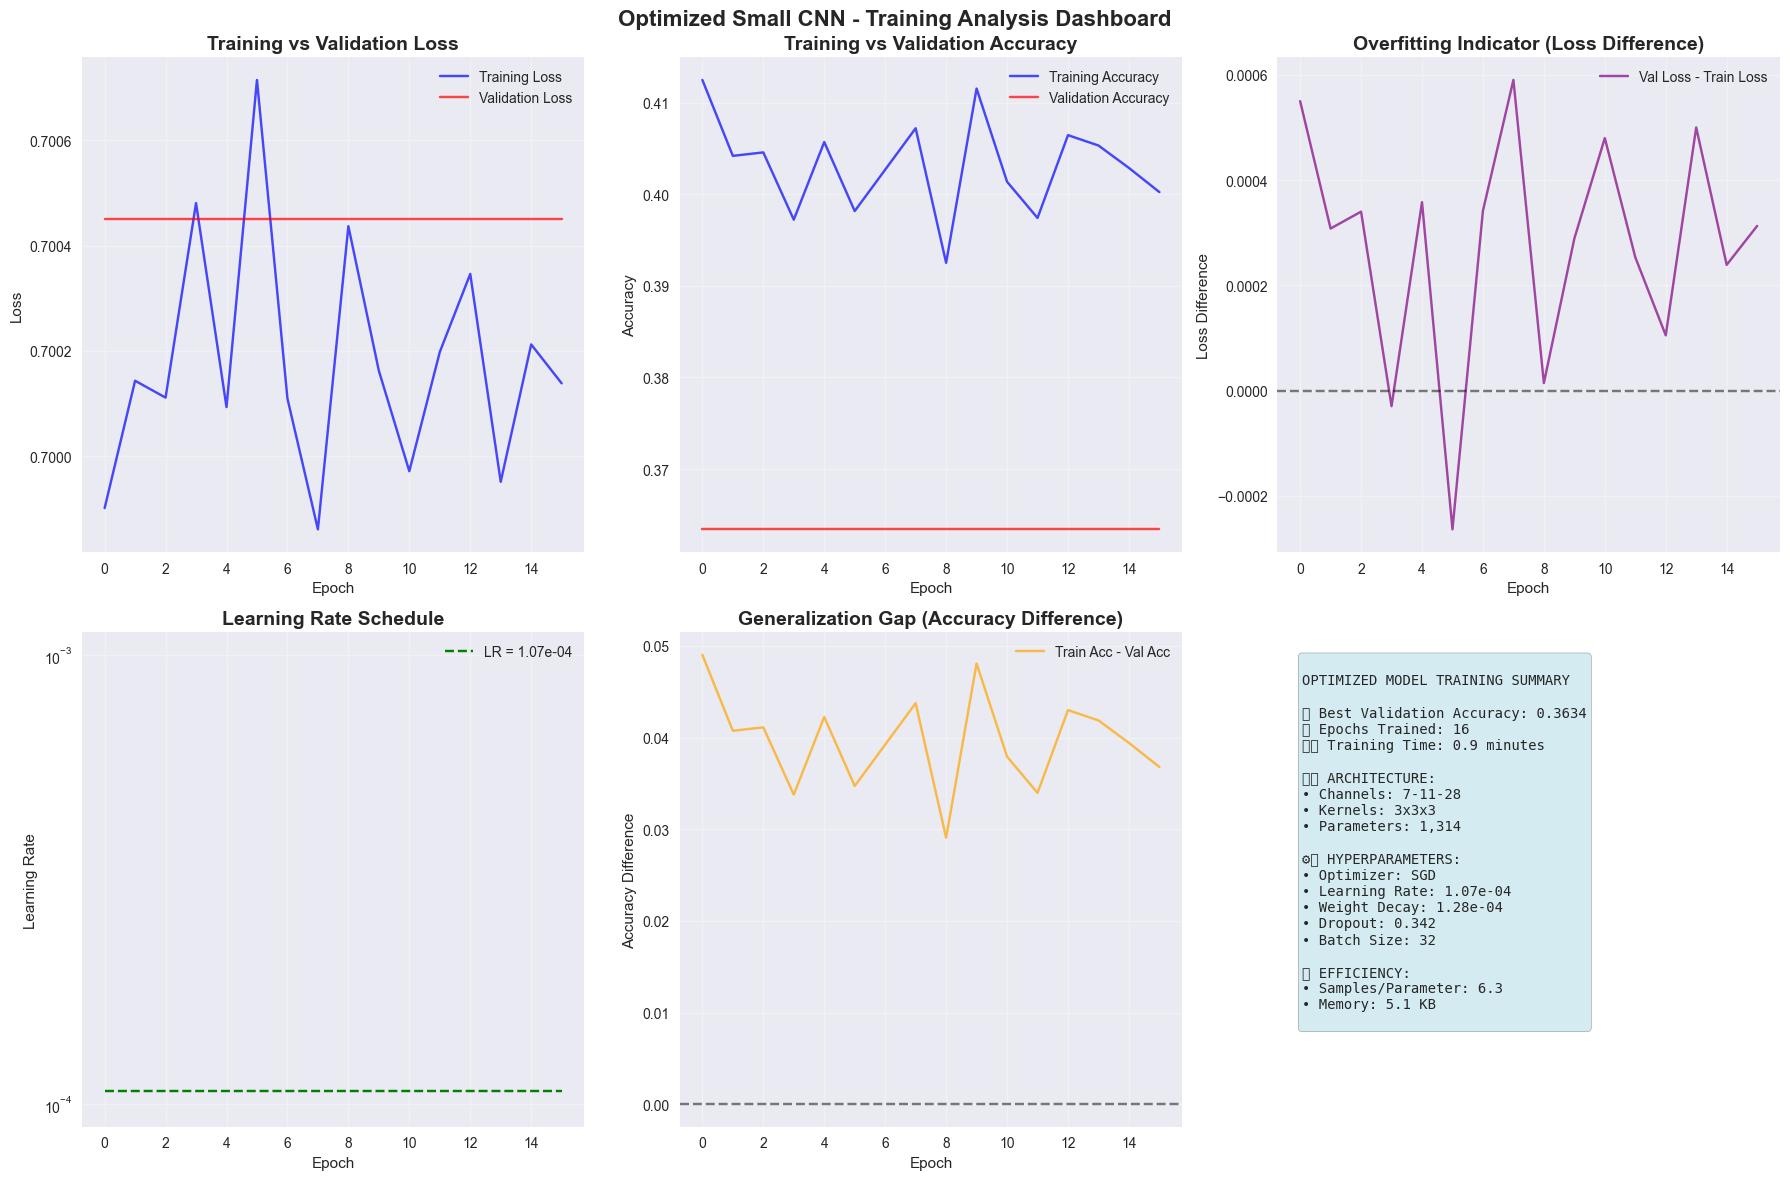

📊 FINAL TRAINING METRICS:
Final training accuracy: 0.4002
Final validation accuracy: 0.3634
Best validation accuracy: 0.3634
Final training loss: 0.7001
Final validation loss: 0.7005


In [19]:
# Comprehensive plotting of training results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Training and Validation Loss
axes[0, 0].plot(training_history['train_losses'], label='Training Loss', color='blue', alpha=0.7)
axes[0, 0].plot(training_history['val_losses'], label='Validation Loss', color='red', alpha=0.7)
axes[0, 0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Training and Validation Accuracy
axes[0, 1].plot(training_history['train_accuracies'], label='Training Accuracy', color='blue', alpha=0.7)
axes[0, 1].plot(training_history['val_accuracies'], label='Validation Accuracy', color='red', alpha=0.7)
axes[0, 1].set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Loss Difference (Overfitting indicator)
loss_diff = np.array(training_history['val_losses']) - np.array(training_history['train_losses'])
axes[0, 2].plot(loss_diff, label='Val Loss - Train Loss', color='purple', alpha=0.7)
axes[0, 2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0, 2].set_title('Overfitting Indicator (Loss Difference)', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss Difference')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Learning Rate Schedule (if applicable)
axes[1, 0].plot([best_params['learning_rate']] * len(training_history['train_losses']), 
               label=f"LR = {best_params['learning_rate']:.2e}", color='green', linestyle='--')
axes[1, 0].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_yscale('log')

# 5. Accuracy Gap (Generalization gap)
acc_gap = np.array(training_history['train_accuracies']) - np.array(training_history['val_accuracies'])
axes[1, 1].plot(acc_gap, label='Train Acc - Val Acc', color='orange', alpha=0.7)
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Generalization Gap (Accuracy Difference)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy Difference')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Training Summary Text
axes[1, 2].axis('off')
summary_text = f"""
OPTIMIZED MODEL TRAINING SUMMARY

🎯 Best Validation Accuracy: {training_history['best_val_acc']:.4f}
📊 Epochs Trained: {training_history['epochs_trained']}
⏱️ Training Time: {training_time/60:.1f} minutes

🏗️ ARCHITECTURE:
• Channels: {best_params['conv1_channels']}-{best_params['conv2_channels']}-{best_params['conv3_channels']}
• Kernels: {best_params['kernel1_size']}x{best_params['kernel2_size']}x{best_params['kernel3_size']}
• Parameters: {arch_summary['total_parameters']:,}

⚙️ HYPERPARAMETERS:
• Optimizer: {best_params['optimizer'].upper()}
• Learning Rate: {best_params['learning_rate']:.2e}
• Weight Decay: {best_params['weight_decay']:.2e}
• Dropout: {best_params['dropout_rate']:.3f}
• Batch Size: {best_params['batch_size']}

📈 EFFICIENCY:
• Samples/Parameter: {len(data_filtered) / arch_summary['total_parameters']:.1f}
• Memory: {arch_summary['total_parameters'] * 4 / 1024:.1f} KB
"""

axes[1, 2].text(0.05, 0.95, summary_text, transform=axes[1, 2].transAxes, 
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.5))

plt.suptitle('Optimized Small CNN - Training Analysis Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print final training metrics
print("📊 FINAL TRAINING METRICS:")
print("="*50)
print(f"Final training accuracy: {training_history['train_accuracies'][-1]:.4f}")
print(f"Final validation accuracy: {training_history['val_accuracies'][-1]:.4f}")
print(f"Best validation accuracy: {training_history['best_val_acc']:.4f}")
print(f"Final training loss: {training_history['train_losses'][-1]:.4f}")
print(f"Final validation loss: {training_history['val_losses'][-1]:.4f}")


🏆 FINAL TEST SET EVALUATION
🎯 Final Test Accuracy: 0.3709

📋 Detailed Classification Report:
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00      1045
     Class 1       0.37      1.00      0.54       616

    accuracy                           0.37      1661
   macro avg       0.19      0.50      0.27      1661
weighted avg       0.14      0.37      0.20      1661


🔢 Confusion Matrix:
True Negatives:   0 | False Positives: 1045
False Negatives:   0 | True Positives: 616

📊 Additional Metrics:
Sensitivity (Recall): 1.0000
Specificity: 0.0000
Precision: 0.3709
F1-Score: 0.5411


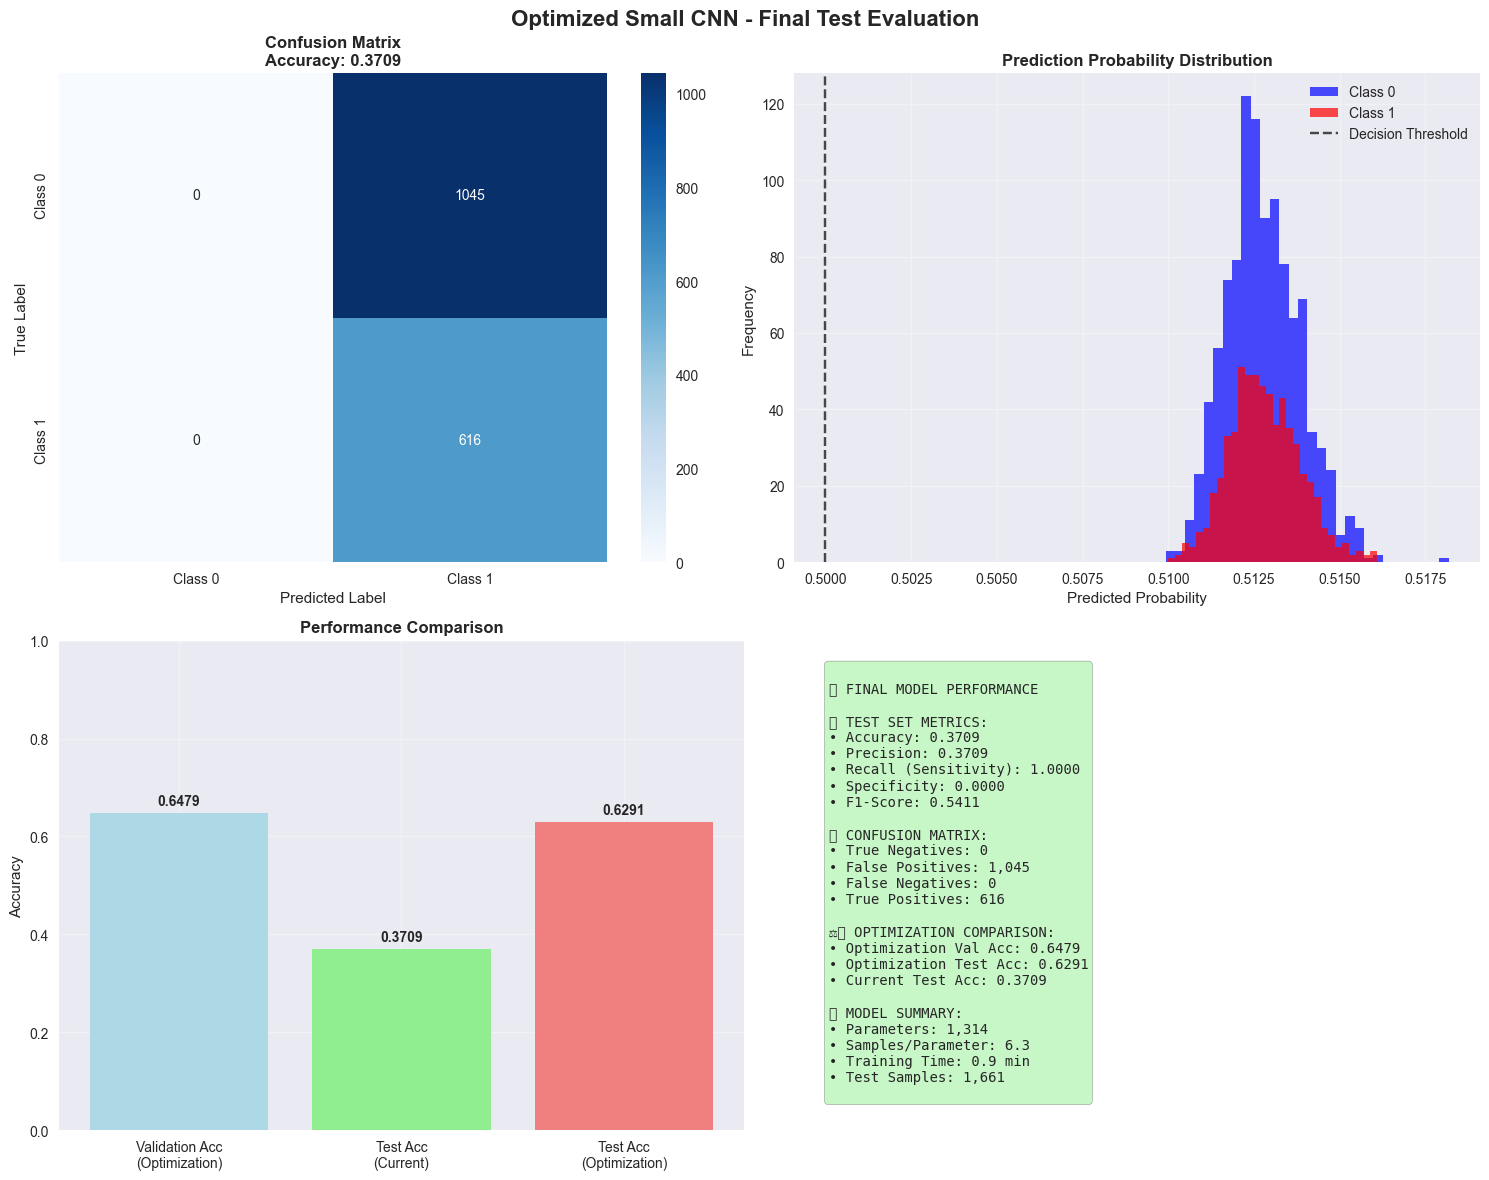


💾 Results saved:
• Model: results/final_optimized_small_cnn.pt
• Results: results/final_optimized_results.json

🎉 Optimized Small CNN evaluation completed successfully!


In [20]:
# Final evaluation on test set
print("🏆 FINAL TEST SET EVALUATION")
print("="*60)

model.eval()
test_predictions = []
test_targets = []
test_probabilities = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.float().to(device)
        output = model(data).squeeze()
        
        # Handle single sample case
        if output.dim() == 0:
            output = output.unsqueeze(0)
        if target.dim() == 0:
            target = target.unsqueeze(0)
        
        predictions = (output > 0.5).float()
        
        test_predictions.extend(predictions.cpu().numpy())
        test_targets.extend(target.cpu().numpy())
        test_probabilities.extend(output.cpu().numpy())

# Calculate comprehensive metrics
test_accuracy = accuracy_score(test_targets, test_predictions)
print(f"🎯 Final Test Accuracy: {test_accuracy:.4f}")

# Classification report
print(f"\n📋 Detailed Classification Report:")
class_report = classification_report(test_targets, test_predictions, 
                                   target_names=['Class 0', 'Class 1'], 
                                   output_dict=True)
print(classification_report(test_targets, test_predictions, 
                           target_names=['Class 0', 'Class 1']))

# Confusion matrix
cm = confusion_matrix(test_targets, test_predictions)
print(f"\n🔢 Confusion Matrix:")
print(f"True Negatives: {cm[0,0]:3d} | False Positives: {cm[0,1]:3d}")
print(f"False Negatives: {cm[1,0]:3d} | True Positives: {cm[1,1]:3d}")

# Additional metrics
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0

print(f"\n📊 Additional Metrics:")
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-Score: {f1_score:.4f}")

# Create comprehensive evaluation plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Class 0', 'Class 1'], 
            yticklabels=['Class 0', 'Class 1'])
axes[0, 0].set_title(f'Confusion Matrix\nAccuracy: {test_accuracy:.4f}', fontweight='bold')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# 2. Prediction Probability Distribution
axes[0, 1].hist([prob for i, prob in enumerate(test_probabilities) if test_targets[i] == 0], 
               bins=30, alpha=0.7, label='Class 0', color='blue')
axes[0, 1].hist([prob for i, prob in enumerate(test_probabilities) if test_targets[i] == 1], 
               bins=30, alpha=0.7, label='Class 1', color='red')
axes[0, 1].axvline(x=0.5, color='black', linestyle='--', alpha=0.7, label='Decision Threshold')
axes[0, 1].set_title('Prediction Probability Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Predicted Probability')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Metrics Comparison (vs Optimization Results)
metrics_comparison = {
    'Metric': ['Validation Acc\n(Optimization)', 'Test Acc\n(Current)', 'Test Acc\n(Optimization)'],
    'Accuracy': [optimization_results['best_value'], test_accuracy, optimization_results['final_test_accuracy']]
}

bars = axes[1, 0].bar(metrics_comparison['Metric'], metrics_comparison['Accuracy'], 
                     color=['lightblue', 'lightgreen', 'lightcoral'])
axes[1, 0].set_title('Performance Comparison', fontweight='bold')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim(0, 1)

# Add value labels on bars
for bar, acc in zip(bars, metrics_comparison['Accuracy']):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

axes[1, 0].grid(True, alpha=0.3)

# 4. Model Performance Summary
axes[1, 1].axis('off')
performance_text = f"""
🏆 FINAL MODEL PERFORMANCE

📈 TEST SET METRICS:
• Accuracy: {test_accuracy:.4f}
• Precision: {precision:.4f}
• Recall (Sensitivity): {sensitivity:.4f}
• Specificity: {specificity:.4f}
• F1-Score: {f1_score:.4f}

🔢 CONFUSION MATRIX:
• True Negatives: {tn:,}
• False Positives: {fp:,}
• False Negatives: {fn:,}
• True Positives: {tp:,}

⚖️ OPTIMIZATION COMPARISON:
• Optimization Val Acc: {optimization_results['best_value']:.4f}
• Optimization Test Acc: {optimization_results['final_test_accuracy']:.4f}
• Current Test Acc: {test_accuracy:.4f}

🎯 MODEL SUMMARY:
• Parameters: {arch_summary['total_parameters']:,}
• Samples/Parameter: {len(data_filtered) / arch_summary['total_parameters']:.1f}
• Training Time: {training_time/60:.1f} min
• Test Samples: {len(test_targets):,}
"""

axes[1, 1].text(0.05, 0.95, performance_text, transform=axes[1, 1].transAxes, 
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.5))

plt.suptitle('Optimized Small CNN - Final Test Evaluation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Save final results
final_results = {
    'model_architecture': arch_summary,
    'hyperparameters': best_params,
    'training_history': training_history,
    'test_metrics': {
        'accuracy': test_accuracy,
        'precision': precision,
        'recall': sensitivity,
        'specificity': specificity,
        'f1_score': f1_score,
        'confusion_matrix': cm.tolist()
    },
    'optimization_comparison': {
        'optimization_val_acc': optimization_results['best_value'],
        'optimization_test_acc': optimization_results['final_test_accuracy'],
        'current_test_acc': test_accuracy
    },
    'training_time_minutes': training_time / 60
}

# Save model and results
torch.save(model.state_dict(), '../../results/final_optimized_small_cnn.pt')
with open('../../results/final_optimized_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print(f"\n💾 Results saved:")
print(f"• Model: results/final_optimized_small_cnn.pt")
print(f"• Results: results/final_optimized_results.json")
print(f"\n🎉 Optimized Small CNN evaluation completed successfully!")


In [21]:
# Create data loaders with optimized batch size
train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'], shuffle=False)

# Setup optimized optimizer (SGD was found to be best)
if best_params['optimizer'] == 'sgd':
    optimizer = optim.SGD(model.parameters(), 
                         lr=best_params['learning_rate'], 
                         weight_decay=best_params['weight_decay'],
                         momentum=0.9)
elif best_params['optimizer'] == 'adam':
    optimizer = optim.Adam(model.parameters(), 
                          lr=best_params['learning_rate'], 
                          weight_decay=best_params['weight_decay'])
else:  # adamw
    optimizer = optim.AdamW(model.parameters(), 
                           lr=best_params['learning_rate'], 
                           weight_decay=best_params['weight_decay'])

criterion = nn.BCELoss()

print("🚀 TRAINING SETUP:")
print("="*50)
print(f"Optimizer: {best_params['optimizer'].upper()}")
print(f"Learning rate: {best_params['learning_rate']:.2e}")
print(f"Weight decay: {best_params['weight_decay']:.2e}")
print(f"Batch size: {best_params['batch_size']}")
print(f"Loss function: Binary Cross Entropy")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

print("\n✅ Training setup completed!")


🚀 TRAINING SETUP:
Optimizer: SGD
Learning rate: 1.07e-04
Weight decay: 1.28e-04
Batch size: 32
Loss function: Binary Cross Entropy
Training batches: 166
Validation batches: 42
Test batches: 52

✅ Training setup completed!
